# 02 - NDMM PBMC Object Generation
### By [Mansi Singh](mansi.singh@alleninstitute.org), Comp Bio, Allen Institute for Immunology
### Original notebook by [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology

**Date created**: 2025-03-11

**Main aim**: 
Attach CellTypist labels, doublet scores, and clinical metadata (cytogenetics, immunoglobulin levels, lipids, CMV, RISS staging) to a filtered set of 193 non-DARA PBMC samples, concatenate into a single master AnnData object, clean up cell-type labels using the AIFI tidy nomenclature (L1/L2/L3 hierarchies), and split the final object into treatment-timepoint and flu-timepoint subsets. All outputs saved to `data/ndmm-raw-files/`.

## 1 Imports and functions

In [ ]:
# Standard library and third-party imports
import gc
import os
import re
import shutil
import sys
import tarfile
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date
from functools import reduce

import anndata
import celltypist
import h5py
import hisepy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as scs
from tqdm import tqdm

warnings.filterwarnings("ignore")  # Suppress deprecation warnings for cleaner output
sc.settings.n_jobs = 60  # Parallelism tuned for HISE compute environment (60 cores)

In [ ]:
# Output directories — create before running build steps
ndmm_pbmc_raw_dir = '../../../data/rna/ndmm-raw-files/'
os.makedirs(ndmm_pbmc_raw_dir, exist_ok=True)

file_path_csvs = '../../../data/rna/ndmm-pbmc-csvs_pkls/'
os.makedirs(file_path_csvs, exist_ok=True)

### Object builders

In [3]:
def read_expression_matrix(h5_file):
    """Reads the expression matrix from an h5 file."""
    matrix = scs.csc_matrix(
        (
            h5_file["matrix"]["data"][:],  # Count values
            h5_file["matrix"]["indices"][:],  # Row indices
            h5_file["matrix"]["indptr"][:],
        ),  # Pointers for column positions
        shape=tuple(h5_file["matrix"]["shape"][:]),  # Matrix dimensions
    )
    return matrix


def read_metadata(h5_file):
    """Reads the metadata from an h5 file."""
    barcodes = h5_file["matrix"]["barcodes"][:]
    barcodes = [barcode.decode("UTF-8") for barcode in barcodes]

    # Initialized the DataFrame with cell barcodes
    metadata_df = pd.DataFrame({"barcodes": barcodes})

    # Get the list of available metadata columns
    metadata_columns = h5_file["matrix"]["observations"].keys()

    # For each column
    for column in metadata_columns:
        # Read the values
        values = h5_file["matrix"]["observations"][column][:]
        # Check for byte storage
        if isinstance(values[0], (bytes, bytearray)):
            # Decode byte strings
            values = [value.decode("UTF-8") for value in values]
        # Add column to the DataFrame
        metadata_df[column] = values

    return metadata_df


def read_h5_anndata(h5_file_path):
    """Constructs an AnnData object from an h5 file."""
    with h5py.File(h5_file_path, mode="r") as h5_file:
        # Extract the expression matrix
        expression_matrix = read_expression_matrix(h5_file)
        # Extract gene names
        gene_names = h5_file["matrix"]["features"]["name"][:]
        gene_names = [gene_name.decode("UTF-8") for gene_name in gene_names]
        # Extract metadata
        metadata_df = read_metadata(h5_file)
        # Construct anndata
        adata = anndata.AnnData(expression_matrix.T, obs=metadata_df)
        # Make sure the gene names aligned
        adata.var_names = gene_names
        adata.var_names_make_unique()

    return adata

In [4]:
celltypist_labels_dir = "../../../data/rna/celltypist_pbmc/labels/"

def get_labels_and_scores(
    pbmc_sample_id, data_sources, celltypist_labels_dir=celltypist_labels_dir, levels=3
):
    """
    For each pbmc_sample_id, extract labels predicted by different methods and combine them into a DataFrame.

    Parameters:
    pbmc_sample_id (str): The sample id to process.
    data_sources (list): List of data sources for different methods.
    levels (int): Number of levels of labels to process. Default is 3.

    Returns:
    DataFrame: DataFrame with the combined labels.
    """

    def load_and_merge(data_source):
        label_dfs = [
            pd.read_csv(
                f"{celltypist_labels_dir}{pbmc_sample_id}_l{i}_{data_source}_predicted_labels.csv"
            )[["barcodes", "predicted_labels"]]
            for i in range(1, levels + 1)
        ]

        merged_label_df = reduce(
            lambda left, right: pd.merge(left, right, on="barcodes", how="left"),
            label_dfs,
        )
        merged_label_df.columns = ["barcodes"] + [
            f"{data_source}_l{i}" for i in range(1, levels + 1)
        ]

        return merged_label_df

    merged_labels = [load_and_merge(data_source) for data_source in data_sources]

    return reduce(
        lambda left, right: pd.merge(left, right, on="barcodes", how="left"),
        merged_labels,
    )

In [ ]:
ndmm_bmmc_raw_dir = "../../../data/rna/ndmm-raw-files/"


def build_adata(
    file_path, metadata, doublet_path, ndmm_bmmc_raw_dir=ndmm_bmmc_raw_dir, save=False
):
    """
    Builds an AnnData object from an h5 expression file, attaching CellTypist labels,
    doublet scores, and clinical metadata.

    Parameters:
    file_path (str): Path to the .h5 expression matrix file.
    metadata (DataFrame): Clinical/sample metadata (filtered for 193 PBMC samples).
    doublet_path (str): Path to the parquet file with pre-computed doublet scores.
    ndmm_bmmc_raw_dir (str): Output directory for per-sample h5ad files.
    save (bool): If True, write the per-sample h5ad to disk.

    Returns:
    AnnData: Assembled AnnData object with expression, metadata, and annotations.
    """
    adata = read_h5_anndata(file_path)
    pbmc_sample_id = adata.obs["pbmc_sample_id"][0]

    # Attach CellTypist labels and doublet scores
    df = get_labels_and_scores(pbmc_sample_id, ["aifi"])
    doublet_scores = pd.read_parquet(doublet_path)
    df = df.merge(doublet_scores, on="barcodes", how="left")
    adata.obs = adata.obs.merge(df, on="barcodes", how="left")

    # Clinical metadata columns to attach, grouped by category:
    add_meta = metadata[
        [
            # Sample identifiers
            "pbmc_sample_id",
            "sample.sampleKitGuid",
            "sample.visitDetails",
            "sample.visitName",
            "sample.drawDate",
            "sample.daysSinceFirstVisit",
            "sample.diseaseStatesRecordedAtVisit",
            # Subject demographics
            "subject.biologicalSex",
            "subject.birthYear",
            "subject.ethnicity",
            "subject.partnerCode",
            "subject.race",
            "subject.subjectGuid",
            # Cohort/specimen
            "cohort.cohortGuid",
            "manual.time_stamp",
            "manual.tissue",
            "manual.disease_condition",
            "manual.response",
            "manual.response_type",
            "manual.extracted_name",
            "manual.file_paths",
            "manual.batch_id",
            # CMV status
            "manual.cmv.ab_screen_index_value",
            "manual.cmv.ab_screen_result",
            "manual.cmv.ab_visit",
            # Immunoglobulin levels
            "manual.igg.iga",
            "manual.igg.igg",
            "manual.igg.igm",
            "manual.igg.immunofixation",
            "manual.igg.k_flc",
            "manual.igg.kl_flc_ratio",
            "manual.igg.l_flc",
            "manual.igg.mono_1_id",
            "manual.igg.mono_1_quant",
            # Lipid panel
            "manual.lip.cholesterol_hdl_ratio",
            "manual.lip.cholesterol_hdl",
            "manual.lip.cholesterol_ldl",
            "manual.lip.cholesterol_non_hdl",
            "manual.lip.cholesterol_total",
            "manual.lip.triglycerides",
            # RISS staging
            "manual.RISS.stage",
            # Cytogenetics
            "manual.cyto.17p_loss",
            "manual.cyto.1q_gain",
            "manual.cyto.1p_loss",
            "manual.cyto.high_risk",
            "manual.cyto.karyotype",
            "manual.cyto.t11_14",
            "manual.cyto.t14_16",
            "manual.cyto.t14_20",
            "manual.cyto.t4_14",
            "manual.cyto.karyotype.1",
        ]
    ]

    adata.obs = adata.obs.merge(add_meta, on="pbmc_sample_id", how="left")
    adata.obs.index = adata.obs.barcodes

    if save:
        pbmc_sample_id = adata.obs["pbmc_sample_id"][0]
        adata.write_h5ad(
            f"{ndmm_bmmc_raw_dir}adata_raw_pbmc_{pbmc_sample_id}.h5ad"
        )
        print(
            "Done saving",
            f"{ndmm_bmmc_raw_dir}adata_raw_pbmc_{pbmc_sample_id}.h5ad",
        )

    return adata

## 2 Get metadata

Pull metadata from `01-sample-collection` and clean up. 

In [6]:
# Download metadata from HISE using UUIDs
file_uuid = ["775c0ad6-489a-43d4-b731-fb45f404fa5c"]

metadata_download_files = hp.cache_files(file_uuid)

In [10]:
ndmm_metadata = pd.read_csv(metadata_download_files[0])

ndmm_metadata["manual.time_stamp"] = pd.to_datetime(ndmm_metadata["manual.time_stamp"])
ndmm_metadata = (
    ndmm_metadata.loc[ndmm_metadata["manual.tissue"] == "PBMC"]
    .loc[:, ~ndmm_metadata.columns.str.contains("^Unnamed")]
    .sort_values(
        by=["sample.sampleKitGuid", "manual.time_stamp"], ascending=[True, False]
    )
    .drop_duplicates(subset="sample.sampleKitGuid", keep="first")
    .reset_index(drop=True)
)

for column in ndmm_metadata.columns:
    if pd.api.types.is_datetime64_any_dtype(ndmm_metadata[column]):
        ndmm_metadata[column] = ndmm_metadata[column].astype(str)

for column in ndmm_metadata.select_dtypes(include="object").columns:
    ndmm_metadata[column] = ndmm_metadata[column].astype("category")

ndmm_metadata.head()

,lastUpdated,sample.id,sample.bridgingControl,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,file.id,...,manual.cyto.17p_loss,manual.cyto.1q_gain,manual.cyto.1p_loss,manual.cyto.high_risk,manual.cyto.karyotype,manual.cyto.t11_14,manual.cyto.t14_16,manual.cyto.t14_20,manual.cyto.t4_14,manual.cyto.karyotype.1
0,2025-02-18T20:59:44.335Z,990f590a-83ab-4c31-95bc-f8bec685e96a,False,KT00132,Other - Non-Flu,MM Pre-Treatment,2020-01-01T00:00:00Z,0,NaN,8f472610-4c00-4daa-bba6-96448a82fffc,...,No,No,No,No,Normal,Yes,No,Not Tested,No,Normal
1,2025-02-18T20:59:44.335Z,ea076b22-4a7c-49fa-9fbc-d38300386cdb,False,KT00133,Other - Non-Flu,MM Pre-Treatment,2020-01-01T00:00:00Z,0,NaN,09e1c4ff-2a64-4bf5-881b-3c1a46fc2c35,...,No,Yes,No,No,Normal,No,No,Not Tested,No,Normal
2,2025-02-18T20:59:44.335Z,a43d2542-b590-476a-bc19-3d07d3df59de,False,KT00134,Other - Non-Flu,MM Pre-Treatment,2020-03-01T00:00:00Z,0,NaN,54731618-60b0-44b5-975e-e17bdd8a95dc,...,No,No,No,No,Abnormal,No,No,Not Tested,No,Abnormal
3,2025-02-18T20:59:44.335Z,687aa7ab-7cc3-4a8f-8c2c-6d94e24c5804,False,KT00135,Other - Non-Flu,MM Post Induction 2-Cycles,2020-04-01T00:00:00Z,67,NaN,64240cb0-0b0c-4f7d-9677-3cbeafaf715e,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested
4,2025-02-18T20:59:44.335Z,7fcef0d1-1a4c-4d59-ba3a-7fbbad731fa4,False,KT00136,Other - Non-Flu,MM Pre-Treatment,2020-04-01T00:00:00Z,0,NaN,2fe3e785-8c98-4410-80fb-ccf91e3a4d33,...,No,No,No,No,Normal,No,No,Not Tested,No,Normal


In [11]:
ndmm_metadata.shape

(194, 61)

In [13]:
ndmm_metadata['sample.sampleKitGuid'].unique()

['KT00132', 'KT00133', 'KT00134', 'KT00135', 'KT00136', ..., 'KT06438', 'KT06440', 'KT06442', 'KT06443', 'KT06445']
Length: 194
Categories (194, object): ['KT00132', 'KT00133', 'KT00134', 'KT00135', ..., 'KT06440', 'KT06442', 'KT06443', 'KT06445']

In [ ]:
# Add treatment and flu response metadata columns
# DARA subjects: identified from clinical protocol (subjects receiving daratumumab)
dara = ["FH1019", "FH1020", "FH1022", "FH1023", "FH1024", "FH1026", "FH1027", "FH1028"]

ndmm_metadata["manual.treatment_dara"] = ndmm_metadata["subject.subjectGuid"].apply(
    lambda x: "dara" if x in dara else "non_dara"
)

# Flu response classification: based on HAI seroconversion criteria from clinical team
NonResponders = ("FH1021", "FH1016", "FH1011", "FH1009", "FH1007", "FH1004", "FH1003")
Responders = ("FH1002", "FH1005", "FH1006", "FH1008", "FH1012", "FH1014", "FH1017")

ndmm_metadata["manual.flu_response"] = ndmm_metadata["subject.subjectGuid"].apply(
    lambda x: (
        "non-responder"
        if x in NonResponders
        else ("responder" if x in Responders else "NA")
    )
)

In [15]:
ndmm_metadata[
    (ndmm_metadata["sample.visitName"] == "Other - Non-Flu")
    & (ndmm_metadata["manual.treatment_dara"] == "non_dara")
]["manual.flu_response"].value_counts()

manual.flu_response
responder        33
non-responder    32
NA                9
Name: count, dtype: int64

In [16]:
ndmm_metadata[
    (ndmm_metadata["sample.visitName"] == "Other - Non-Flu")
    & (ndmm_metadata["manual.treatment_dara"] == "non_dara")
]["sample.visitDetails"].value_counts()

sample.visitDetails
MM Pre-Treatment                   17
MM Post Induction 2-Cycles         16
MM End Induction 1st Draw          14
MM Post Transplant 60 Days         12
MM Post Transplant 1 year           9
MM Post Transplant 2 year           6
MM Post Transplant 90 Days          0
N/A - Flu-Series Timepoint Only     0
Name: count, dtype: int64

In [17]:
file_paths = ndmm_metadata["manual.file_paths"].to_list()
len(file_paths)

194

In [1]:
# list of all the 193 samples working with for this analysis
# 74 treatments timepoint
# 119 flu timepoints
my_list = ['KT00244',
'KT00133',
'KT00247',
'KT00236',
'KT00138',
'KT00249',
'KT00132',
'KT00251',
'KT00240',
'KT01315',
'KT00241',
'KT00233',
'KT00250',
'KT00246',
'KT00237',
'KT00139',
'KT00134',
'KT01316',
'KT00234',
'KT00239',
'KT00238',
'KT00136',
'KT00243',
'KT00248',
'KT01317',
'KT00137',
'KT00245',
'KT00235',
'KT00135',
'KT00242',
'KT01322',
'KT01318',
'KT01328',
'KT01333',
'KT01339',
'KT01325',
'KT01319',
'KT01321',
'KT01335',
'KT01329',
'KT01323',
'KT01324',
'KT01326',
'KT01334',
'KT02047',
'KT01364',
'KT01331',
'KT01337',
'KT01358',
'KT01350',
'KT02049',
'KT01360',
'KT02051',
'KT02050',
'KT01357',
'KT01351',
'KT01348',
'KT01356',
'KT02052',
'KT02053',
'KT02055',
'KT02056',
'KT02062',
'KT02066',
'KT02063',
'KT02054',
'KT02065',
'KT02064',
'KT02059',
'KT02060',
'KT02061',
'KT02069',
'KT02068',
'KT02067',
'KT02073',
'KT02078',
'KT02071',
'KT02057',
'KT02080',
'KT02070',
'KT02079',
'KT02084',
'KT02076',
'KT02072',
'KT02081',
'KT02082',
'KT02087',
'KT02088',
'KT02085',
'KT02091',
'KT02094',
'KT02679',
'KT02688',
'KT02686',
'KT02695',
'KT02681',
'KT02709',
'KT02691',
'KT02739',
'KT02689',
'KT02728',
'KT02737',
'KT02697',
'KT02738',
'KT02732',
'KT02752',
'KT02733',
'KT02757',
'KT02729',
'KT02735',
'KT02747',
'KT02750',
'KT02745',
'KT02762',
'KT02763',
'KT02726',
'KT02740',
'KT02767',
'KT02770',
'KT02768',
'KT02771',
'KT02772',
'KT04528',
'KT04527',
'KT04532',
'KT04615',
'KT04531',
'KT04680',
'KT04681',
'KT04679',
'KT04677',
'KT04686',
'KT04683',
'KT04682',
'KT04684',
'KT04685',
'KT04689',
'KT04693',
'KT04694',
'KT04700',
'KT04697',
'KT04698',
'KT04807',
'KT04692',
'KT04695',
'KT04696',
'KT04701',
'KT04811',
'KT04809',
'KT04810',
'KT04824',
'KT04831',
'KT04828',
'KT04835',
'KT04837',
'KT05008',
'KT04836',
'KT04840',
'KT04838',
'KT04825',
'KT05006',
'KT04842',
'KT04845',
'KT05124',
'KT05007',
'KT05119',
'KT04847',
'KT04848',
'KT05116',
'KT05128',
'KT05127',
'KT05130',
'KT05148',
'KT05147',
'KT05138',
'KT06420',
'KT06422',
'KT05133',
'KT06423',
'KT06424',
'KT06431',
'KT06425',
'KT06430',
'KT06427',
'KT06429',
'KT06426',
'KT06442',
'KT06435',
'KT06438',
'KT06437',
'KT06440',
'KT06443',
'KT06445']
print(len(my_list))

193


In [43]:
## filter the metadata for only the 193 selected samples 
filtered_metadata = ndmm_metadata[ndmm_metadata['sample.sampleKitGuid'].isin(my_list)]
filtered_metadata.shape

(193, 63)

In [ ]:
# Remap file paths from HISE input bucket to local workspace mount
filtered_metadata["manual.file_paths_full"] = (
    filtered_metadata["manual.file_paths"].str.replace(
        "../../../data/rna/ndmm-raw-h5", "../../../data/rna/ndmm-raw-h5", regex=False
    )
)

In [45]:
filtered_metadata.to_csv('../../../data/rna/metadata_filtered.csv')

### 2.2 Get Doublet Scores
> Make sure you update this to the right path

In [46]:
doublet_file_path = "../../../data/rna/ndmm-pbmc-csvs_pkls/all_pbmc_doublet_scores.parquet"

### 2.3 Get CellType Labels

In [47]:
def count_files_in_directory(directory_path):
    return len(
        [
            name
            for name in os.listdir(directory_path)
            if os.path.isfile(os.path.join(directory_path, name))
        ]
    )


file_path_labels = "../../../data/rna/celltypist_pbmc/labels/"
file_count = count_files_in_directory(file_path_labels)
print(f"There are {file_count} files in the directory.")

There are 1782 files in the directory.


## 3 Build and save master object

**Note:** One sample file intermittently fails during processing. If a failure occurs, the exception is logged per-file and processing continues for remaining samples.

In [48]:
file_paths = filtered_metadata["manual.file_paths_full"].to_list()
len(file_paths)

193

In [ ]:
# Build all 193 per-sample AnnData objects in parallel
adata_list = []
with ThreadPoolExecutor(max_workers=30) as executor:
    future_to_file = {
        executor.submit(
            build_adata,
            file_path,
            filtered_metadata,
            doublet_file_path,
            ndmm_bmmc_raw_dir,
            save=True,
        ): file_path
        for file_path in file_paths
    }
    for future in tqdm(as_completed(future_to_file), total=len(file_paths)):
        file_path = future_to_file[future]
        try:
            result = future.result()
            if result is not None:
                adata_list.append(result)
        except Exception as e:
            # BUG FIX: was previously printing `file_paths` (entire list) instead of `file_path`
            print(f"File {file_path} failed with exception: {e}")

  0%|          | 0/193 [00:00<?, ?it/s]... storing 'batch_id' as categorical
... storing 'batch_id' as categorical
... storing 'chip_id' as categorical
... storing 'hto_barcode' as categorical
... storing 'hto_category' as categorical
... storing 'chip_id' as categorical
... storing 'hto_barcode' as categorical
... storing 'hto_category' as categorical
... storing 'original_barcodes' as categorical
... storing 'original_barcodes' as categorical
... storing 'pbmc_sample_id' as categorical
... storing 'pbmc_sample_id' as categorical
... storing 'pool_id' as categorical
... storing 'pool_id' as categorical
... storing 'seurat_pbmc_type' as categorical
... storing 'seurat_pbmc_type' as categorical
... storing 'well_id' as categorical
... storing 'well_id' as categorical
... storing 'aifi_l1' as categorical
... storing 'aifi_l1' as categorical
... storing 'aifi_l2' as categorical
... storing 'aifi_l2' as categorical
... storing 'aifi_l3' as categorical
... storing 'aifi_l3' as categorical
.

Done saving data/ndmm-raw-files/adata_raw_pbmc_PB00235-01.h5ad


  1%|          | 2/193 [02:08<2:49:23, 53.21s/it] 

Done saving data/ndmm-raw-files/adata_raw_pbmc_PB01317-02.h5ad


  2%|▏         | 3/193 [02:09<1:32:18, 29.15s/it]

...

 98%|█████████▊| 190/193 [13:43<00:00,  5.25it/s]

Done saving data/ndmm-raw-files/adata_raw_pbmc_PB06442-001.h5ad
Done saving data/ndmm-raw-files/adata_raw_pbmc_PB06438-001.h5ad


 99%|█████████▉| 191/193 [13:43<00:00,  5.37it/s]

Done saving data/ndmm-raw-files/adata_raw_pbmc_PB06445-001.h5ad
Done saving data/ndmm-raw-files/adata_raw_pbmc_PB06435-001.h5ad


100%|██████████| 193/193 [13:43<00:00,  4.27s/it]


In [69]:
len(adata_list)

193

In [70]:
# join all the adata objects together
adata = anndata.concat(adata_list)
del adata_list
gc.collect()

0

## 4 Clean up the cell type labels
> Here we're going to assume any cell thats labelled Child A at L3 will belong to Parent A at L1. 

In [ ]:
# Load the AIFI tidy nomenclature for consistent L1/L2/L3 cell type hierarchies
tidy_aifi = pd.read_csv("../../../data/rna/AIFI_pbmc_type_order_and_colorset_2024-05-08.csv")
tidy_aifi = tidy_aifi.rename(columns={
    "AIFI_L3": "l3_label",
    "AIFI_L2": "l2_label",
    "AIFI_L1": "l1_label"
})

label_names = tidy_aifi[["l1_label", "l2_label", "l3_label"]].drop_duplicates()
label_names = label_names.apply(
    lambda col: col.str.rstrip() if col.dtype == "object" else col
)

# Map L3 → L2: each L3 label is assigned its parent L2 category
l3_to_l2 = dict(zip(label_names["l3_label"], label_names["l2_label"]))
adata.obs["tidy.aifi_l2"] = [
    l3_to_l2[x] if x in l3_to_l2 else x for x in adata.obs["aifi_l3"]
]

# Map L2 → L1: each L2 label is assigned its parent L1 category
l2_to_l1 = dict(zip(label_names["l2_label"], label_names["l1_label"]))
adata.obs["tidy.aifi_l1"] = [
    l2_to_l1[x] if x in l2_to_l1 else x for x in adata.obs["tidy.aifi_l2"]
]

# Correct L1 assignments: these L3 types sometimes fall through as unmapped
# "Core naive CD8 T cell" and "CD8aa" should map to "T cell" at L1
adata.obs["tidy.aifi_l1"] = adata.obs["tidy.aifi_l1"].replace(
    {"Core naive CD8 T cell": "T cell", "CD8aa": "T cell"}
)

# Collapse rare/non-immune cell types into "Other" at L1
adata.obs["tidy.aifi_l1"] = adata.obs["tidy.aifi_l1"].replace(
    {
        "Platelet": "Other",
        "Progenitor cell": "Other",
        "ILC": "Other",
        "Erythrocyte": "Other",
    }
)

# Preserve original L3 labels as tidy.aifi_l3
adata.obs["tidy.aifi_l3"] = adata.obs["aifi_l3"]

In [59]:
adata.obs

,barcodes,batch_id,cell_name,cell_uuid,chip_id,hto_barcode,hto_category,n_genes,n_mito_umis,n_reads,...,manual.cyto.high_risk,manual.cyto.karyotype,manual.cyto.t11_14,manual.cyto.t14_16,manual.cyto.t14_20,manual.cyto.t4_14,manual.cyto.karyotype.1,tidy.aifi_l2,tidy.aifi_l1,tidy.aifi_l3
barcodes,,,,,,,,,,,,,,,,,,,,,
175a368acf5711eb92edee87f7fe9c5f,175a368acf5711eb92edee87f7fe9c5f,B017,entitled_amateurish_emu,175a368acf5711eb92edee87f7fe9c5f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,1740,290,25773,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Naive CD4 T cell,T cell,Core naive CD4 T cell
175a3a7ccf5711eb92edee87f7fe9c5f,175a3a7ccf5711eb92edee87f7fe9c5f,B017,hexametral_witching_johndory,175a3a7ccf5711eb92edee87f7fe9c5f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,1229,56,14704,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Naive CD4 T cell,T cell,Core naive CD4 T cell
175a54c6cf5711eb92edee87f7fe9c5f,175a54c6cf5711eb92edee87f7fe9c5f,B017,curvy_meagre_kingbird,175a54c6cf5711eb92edee87f7fe9c5f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,3426,479,51565,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,CD14 monocyte,Monocyte,ISG+ CD14 monocyte
175a5584cf5711eb92edee87f7fe9c5f,175a5584cf5711eb92edee87f7fe9c5f,B017,wounded_revenued_elephant,175a5584cf5711eb92edee87f7fe9c5f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,1573,88,21264,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Naive CD4 T cell,T cell,Core naive CD4 T cell
175a56f6cf5711eb92edee87f7fe9c5f,175a56f6cf5711eb92edee87f7fe9c5f,B017,ameboid_cutprice_bat,175a56f6cf5711eb92edee87f7fe9c5f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,2053,203,27159,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Memory CD4 T cell,T cell,GZMB- CD27+ EM CD4 T cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6d42f390e2c611ee9dcef218033ca531,6d42f390e2c611ee9dcef218033ca531,B205,immovable_lyrical_killdeer,6d42f390e2c611ee9dcef218033ca531,B205-P2C3,TTCCGCCTCTCTTTG,singlet,1454,189,24323,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Memory CD8 T cell,T cell,KLRF1- GZMB+ CD27- EM CD8 T cell
6d430c18e2c611ee9dcef218033ca531,6d430c18e2c611ee9dcef218033ca531,B205,fossillike_hurried_gourami,6d430c18e2c611ee9dcef218033ca531,B205-P2C3,TTCCGCCTCTCTTTG,singlet,1467,229,21756,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Memory CD8 T cell,T cell,GZMK+ CD27+ EM CD8 T cell
6d430ef2e2c611ee9dcef218033ca531,6d430ef2e2c611ee9dcef218033ca531,B205,churchly_cocky_indianabat,6d430ef2e2c611ee9dcef218033ca531,B205-P2C3,TTCCGCCTCTCTTTG,singlet,1245,121,21720,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Memory CD8 T cell,T cell,KLRF1- GZMB+ CD27- EM CD8 T cell


## 5 Save your files
> Using a general date logic here. Edit to change per your preference.

In [ ]:
# Save total object
today_str = date.today().strftime("%Y-%m-%d")
adata.write_h5ad(f"{ndmm_pbmc_raw_dir}{today_str}-ndmm-pbmc-all-raw.h5ad")
adata.obs.to_csv(f"{file_path_csvs}{today_str}-ndmm-pbmc-raw-all-metadata.csv")

# Split object by Flu: "Other - Non-Flu" visits correspond to treatment timepoints
ad_flu = adata[adata.obs["sample.visitName"] != "Other - Non-Flu"]
ad_flu.write_h5ad(f"{ndmm_pbmc_raw_dir}{today_str}-ndmm-pbmc-flu-raw.h5ad")
ad_flu.obs.to_csv(f"{file_path_csvs}{today_str}-ndmm-pbmc-flu-raw-metadata.csv")

# Split object by Treatment: keep only treatment (non-flu) timepoints
ad_tx = adata[adata.obs["sample.visitName"] == "Other - Non-Flu"]
ad_tx.write_h5ad(f"{ndmm_pbmc_raw_dir}{today_str}-ndmm-pbmc-tx-raw.h5ad")
ad_tx.obs.to_csv(f"{file_path_csvs}{today_str}-ndmm-pbmc-raw-tx-metadata.csv")

... storing 'cell_name' as categorical
... storing 'tidy.aifi_l2' as categorical
... storing 'tidy.aifi_l1' as categorical


In [61]:
ad_flu # checking flu object

View of AnnData object with n_obs × n_vars = 1565580 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'manual.tissue', 'manual.disease_condition', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.file_paths', 'manual.batch_id', 'manual.cmv.ab_screen_index_value', 'manual.cmv.ab_screen_result', 'manual.cmv.ab_visit', 'manual.igg.iga', 'manua

In [62]:
ad_tx # checking treatement only object

View of AnnData object with n_obs × n_vars = 1646710 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'manual.tissue', 'manual.disease_condition', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.file_paths', 'manual.batch_id', 'manual.cmv.ab_screen_index_value', 'manual.cmv.ab_screen_result', 'manual.cmv.ab_visit', 'manual.igg.iga', 'manua

In [63]:
adata # checking full object

AnnData object with n_obs × n_vars = 3212290 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'manual.tissue', 'manual.disease_condition', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.file_paths', 'manual.batch_id', 'manual.cmv.ab_screen_index_value', 'manual.cmv.ab_screen_result', 'manual.cmv.ab_visit', 'manual.igg.iga', 'manual.igg.ig

In [ ]:
# Sanity check: Treatment + Flu cell counts should equal total
1646710 + 1565580

3212290

#  QC: Checking the raw cell counts across L3 celltypes before doublet removal

In [15]:
before_doublets = pd.read_csv('../../../data/rna/ndmm-pbmc-csvs_pkls/2025-06-20-ndmm-pbmc-raw-all-metadata.csv') # read the saved csv before any doublet removal to check the raw cell count across all L3 celltypes

In [21]:
# Before doublets
# Group by 'AIFI_L3' and count occurrences
counts_df_before = before_doublets.groupby('tidy.aifi_l3').size().reset_index(name='count_before')

# Display the counts table
print(counts_df_before)


                      tidy.aifi_l3  count_before
0                             ASDC           678
1          Activated memory B cell          1231
2                 Adaptive NK cell         62887
3                     BaEoMaP cell           183
4               C1Q+ CD16 monocyte         12561
..                             ...           ...
66          SOX4+ naive CD8 T cell           314
67             Transitional B cell         31804
68  Type 2 polarized memory B cell           718
69                            cDC1          2088
70                             pDC          8012

[71 rows x 2 columns]


In [22]:
before_doublets.shape

(3212290, 78)

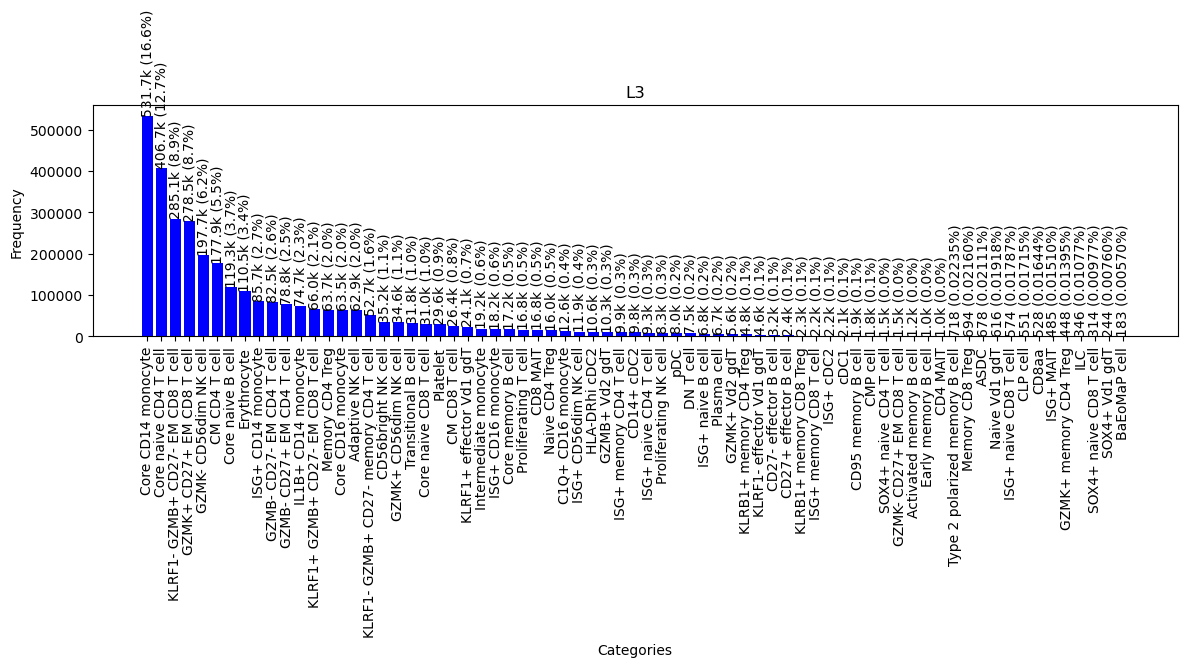

In [40]:
# checking  cell counts on a per L3 celltype basis
frequency_count_sorted = df.sort_values('count_before',ascending=False)

frequency_count_sorted.index=frequency_count_sorted['tidy.aifi_l3']
frequency_count_sorted=frequency_count_sorted['count_before']

plt.figure(figsize=(14, 3))  
total_frequency = sum(frequency_count_sorted)

bars = plt.bar(list(frequency_count_sorted.keys()), list(frequency_count_sorted.values), color='blue')

for bar in bars:
    height = bar.get_height()  
    percentage = (height / total_frequency) * 100 
    
    # Formatting the label with 'k' for thousands
    if height >= 1000:
        label = f"{height/1000:.1f}k ({percentage:.1f}%)"
    else:
        label = f"{int(height)} ({percentage:.5f}%)"

    plt.text(bar.get_x() + bar.get_width() / 2, height, label, 
             va='bottom', ha='center', rotation='vertical')  

plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.title('L3')
plt.xticks(rotation='vertical')  

plt.show()



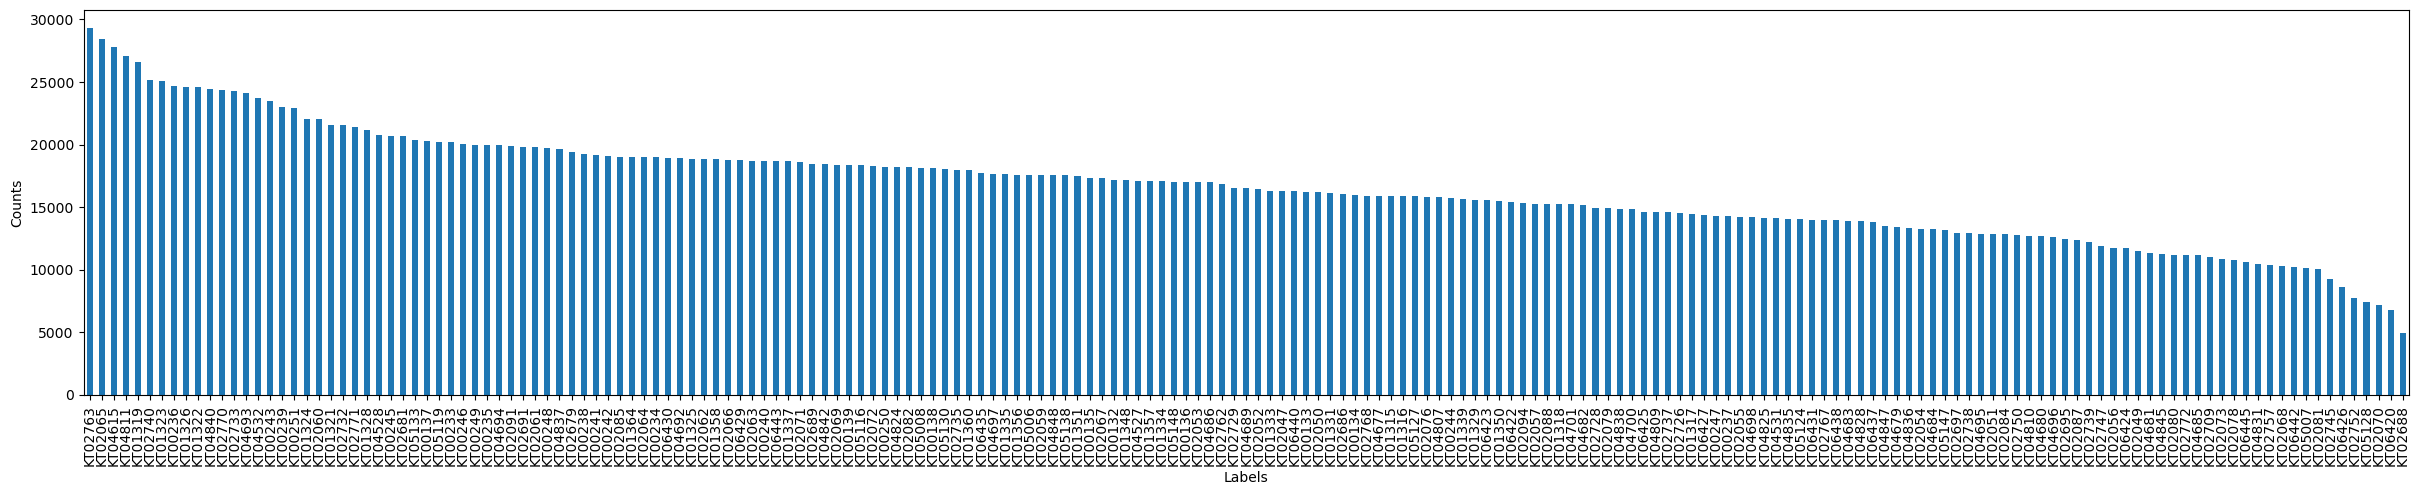

In [37]:
#checking cell counts on a per sample basis
plt.style.use('default')
plt.figure(figsize=(30, 5))
before_doublets['sample.sampleKitGuid'].value_counts().plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.show()